### STEP A. 데이터 준비


In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../1_sql/data/cookie_cats.csv')

# 타겟 변수: D7 이탈 여부 (0=잔존, 1=이탈)
df['retained_d7'] = df['retention_7'].apply(lambda x:1 if x==False else 0)

# 독립 변수: version(A/B그룹), sum_gamerounds(플레이 라운드 수), D1 이탈 여부
df['retained_d1'] = df['retention_1'].apply(lambda x:1 if x==False else 0)
df['version_encoded'] = LabelEncoder().fit_transform(df['version'])
# gate_30 = 0, gate_40 = 1 로 인코딩됨

print(df[['version_encoded', 'sum_gamerounds', 'retained_d1', 'retained_d7']].head())


   version_encoded  sum_gamerounds  retained_d1  retained_d7
0                0               3            1            1
1                0              38            0            1
2                1             165            0            1
3                1               1            1            1
4                1             179            0            0


### STEP B. 학습/테스트 데이터 준비

In [4]:
# 독립변수(X)와 타겟변수(y) 설정
X = df[['version_encoded', 'sum_gamerounds', 'retained_d1']]
y = df['retained_d7']

# 8:2 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습 데이터: {len(X_train):,}행")
print(f"테스트 데이터: {len(X_test):,}행")

학습 데이터: 72,151행
테스트 데이터: 18,038행


### C. 모델 학습

In [5]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# 각 변수의 계수 확인
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("[ 변수별 계수 ]")
print(coef_df)

[ 변수별 계수 ]
           feature  coefficient
2      retained_d1     0.703784
0  version_encoded     0.063881
1   sum_gamerounds    -0.018301


### STEP D. 통계적 유의성 확인

In [8]:
import statsmodels.api as sm

# statsmodels는 상수항(intercept)을 자동으로 더해주지 않으므로 직접 추가해야 합니다.
X_train_sm = sm.add_constant(X_train)

# 모델 생성 및 학습 (Logit 사용)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# 상세 결과 출력
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.327260
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            retained_d7   No. Observations:                72151
Model:                          Logit   Df Residuals:                    72147
Method:                           MLE   Df Model:                            3
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.3183
Time:                        13:30:08   Log-Likelihood:                -23612.
converged:                       True   LL-Null:                       -34635.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.2807      0.025     90.641      0.000       2.231       2.330
version_encode

/opt/miniconda3/envs/py310/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/miniconda3/envs/py310/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


### 통계분석 결과
- retained_d1, sum_gamerounds, version_encoded 모두 p-value가 유의수준 0.05보다 작음

- 이는 각 변수가 D7 이탈 여부를 설명하는 데 있어 유의미한 영향력을 미치고 있음을 뜻함

- 그중 D1 이탈(retained_d1)은 D7 이탈(retained_d7)의 가장 강력한 요인

### STEP E. 모델 평가

[ 분류 리포트 ]
              precision    recall  f1-score   support

           0       0.78      0.42      0.55      3377
           1       0.88      0.97      0.92     14661

    accuracy                           0.87     18038
   macro avg       0.83      0.70      0.74     18038
weighted avg       0.86      0.87      0.85     18038



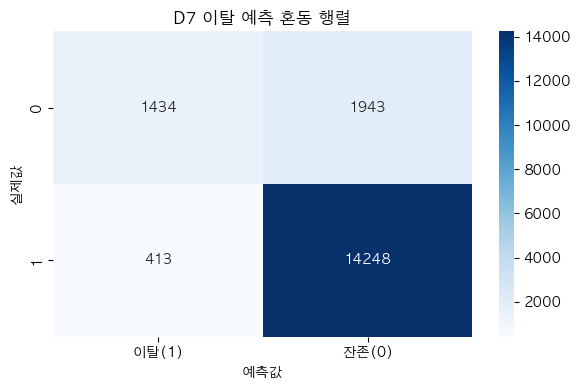

In [7]:
y_pred = model.predict(X_test)
print("[ 분류 리포트 ]")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.rc('font', family='AppleGothic')  # Mac용 AppleGothic 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['이탈(1)', '잔존(0)'])
plt.title('D7 이탈 예측 혼동 행렬')
plt.ylabel('실제값')
plt.xlabel('예측값')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

## D7 이탈 예측 분석 결론
### 1. 핵심 변수 분석

**(1) D1 미접속의 결정적 영향 (retained_d1 계수: 0.7043)**
- D1에 접속하지 않은 유저는 접속한 유저보다 D7에 이탈할 확률이 약 2.02배 높음 <br><br>

**(2) 게이트 위치 변경의 부작용 (version_encoded 계수: 0.0639)**
- 게이트 40레벨 그룹은 30레벨 그룹에 비해 이탈 확률이 약 6.6% 높게 나타남 <br><br>

**(3) 플레이 몰입도와 이탈의 상관관계 (sum_gamerounds 계수: -0.0183)**
- 플레이 라운드 수가 1회 늘어날수록 이탈 확률은 1.8%씩 감소함

### 2. 비즈니스 액션 아이템
**(1) 골든타임(D1) 집중 관리**
- D7 이탈을 막기 위한 가장 효율적인 방법은 D1 미접속을 방지하는 것임<br><br>
- 가입 첫날 유저가 이탈 징후를 보일 경우 즉각적인 Re-engagement(푸시 알림, 접속 보상 등) 전략이 필요함<br><br>

**(2) 게이트 위치 롤백(Roll-back) 고려**
- A/B 테스트 결과, 게이트를 늦게 배치(40레벨)하는 것이 오히려 유저의 피로도를 높여 이탈을 유발하는 것으로 분석됨<br><br>
- 게이트를 기존 30레벨로 유지할 것을 권장함<br><br>

**(3) 초반 라운드 몰입 요소 강화**
- 유저가 게이트를 만나기 전까지 충분한 재미를 느낄 수 있도록 초반 30라운드 이내의 난이도 조절 및 보상 설계가 필요함